# XGBoost — AQI Forecasting

**Why XGBoost:**
- **Task:** Regression — predict a continuous AQI value (same target as Ridge).
- **Bias reduction:** Boosting sequentially corrects residual errors, reducing bias that bagging (Random Forest) leaves behind.
- **Severe days:** XGBoost focuses on hard-to-predict samples, improving tail performance.
- **Same pipeline:** We use the same features, temporal split, log-target training, and evaluation (RMSE, MAE, R², per-category MAE) as in `preprocessing.py` and the baseline.

In [4]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

from preprocessing import (
    load_and_prepare, impute, build_features,
    get_train_test, get_arrays, evaluate, save_results,
    AQI_LABELS, CUTOFF_DATE,
)

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Load data and split into train / validation / test

Same preprocessing as every other notebook. We add a **temporal validation window** (Oct–Nov 2019) carved from training data — this is used for early stopping and hyperparameter tuning without touching the test set.

In [5]:
df = load_and_prepare()
df = impute(df)
df, feature_cols = build_features(df)

# --- temporal splits ---
VAL_CUTOFF = pd.Timestamp('2019-10-01')

full_train_df = df[df['date'] < CUTOFF_DATE].copy().reset_index(drop=True)
test_df       = df[df['date'] >= CUTOFF_DATE].copy().reset_index(drop=True)

train_df = full_train_df[full_train_df['date'] < VAL_CUTOFF].reset_index(drop=True)
val_df   = full_train_df[full_train_df['date'] >= VAL_CUTOFF].reset_index(drop=True)

# arrays for train-sub / val
X_train_sub, X_val, y_train_sub_log, y_val_raw, y_val_log = get_arrays(train_df, val_df, feature_cols)

# arrays for full-train / test (used after tuning)
X_train_full, X_test, y_train_full_log, y_test_raw, y_test_log = get_arrays(full_train_df, test_df, feature_cols)

print(f'Features: {len(feature_cols)}')
print(f'Train-sub: {X_train_sub.shape[0]:,} | Val: {X_val.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Train dates: ... to {train_df["date"].max().date()}')
print(f'Val dates:   {val_df["date"].min().date()} to {val_df["date"].max().date()}')
print(f'Test dates:  {test_df["date"].min().date()} to {test_df["date"].max().date()}')

Features: 70
Train-sub: 18,431 | Val: 1,319 | Test: 5,100
Train dates: ... to 2019-09-30
Val dates:   2019-10-01 to 2019-11-30
Test dates:  2019-12-01 to 2020-07-01


## 2. Sample weights for severe-day emphasis

AQI follows a heavy right skew — most days are Good/Satisfactory, but **Severe days are the most important to predict accurately.** We compute sample weights so the model pays more attention to extreme events during training.

In [6]:
from preprocessing import AQI_BINS

def make_sample_weights(y_log, bins=AQI_BINS):
    """Higher weight for rarer / more extreme AQI categories."""
    y_raw = np.expm1(y_log)
    cats = pd.cut(pd.Series(y_raw), bins=bins, labels=AQI_LABELS)
    freq = cats.value_counts(normalize=True)
    # inverse-frequency weighting, capped so Severe doesn't dominate entirely
    cat_weight = {c: min(1.0 / max(f, 1e-4), 20.0) for c, f in freq.items()}
    weights = cats.map(cat_weight).values.astype(float)
    # normalise so mean weight ≈ 1
    weights /= weights.mean()
    return weights

# weights for the train-sub (used during tuning)
w_train_sub = make_sample_weights(y_train_sub_log)
# weights for the full training set (used for final model)
w_train_full = make_sample_weights(y_train_full_log)

print('Sample weight by AQI category (train-sub):')
y_raw_sub = np.expm1(y_train_sub_log)
cats = pd.cut(pd.Series(y_raw_sub), bins=AQI_BINS, labels=AQI_LABELS)
for cat in AQI_LABELS:
    mask = (cats == cat).values
    if mask.sum() > 0:
        print(f'  {cat:>14s}: n={mask.sum():>5,}  avg weight={w_train_sub[mask].mean():.2f}')

Sample weight by AQI category (train-sub):
            Good: n=  753  avg weight=3.44
    Satisfactory: n=5,485  avg weight=0.58
        Moderate: n=6,811  avg weight=0.47
            Poor: n=2,184  avg weight=1.45
       Very Poor: n=1,980  avg weight=1.60
          Severe: n=1,218  avg weight=2.60


## 2.5 Baseline (untuned) XGBoost

Before tuning, we train a **baseline** XGBoost with fixed hyperparameters (no search, no sample weights). We use the same train-sub / test split and evaluate with the same metrics (RMSE, MAE, R², per-category MAE)

In [ ]:
# Baseline config (same as tree_models.ipynb simple XGBoost — no tuning, no sample weights)
xgb_baseline = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror',
)
xgb_baseline.fit(X_train_sub, y_train_sub_log)

# Same test evaluation as the tuned model
y_pred_log_baseline = xgb_baseline.predict(X_test)
y_pred_raw_baseline = np.clip(np.expm1(y_pred_log_baseline), 0, None)

result_baseline = evaluate(y_test_raw, y_pred_raw_baseline, label='XGBoost baseline')



──────────────────────────────────────────────────────
  XGBoost baseline
──────────────────────────────────────────────────────
  RMSE :    21.96
  MAE  :    11.57
  R²   :   0.9410
  MAE by AQI category:
              Good:    6.84  (n=535)
      Satisfactory:    7.29  (n=2,116)
          Moderate:   12.13  (n=1,746)
              Poor:   22.98  (n=406)
         Very Poor:   19.62  (n=236)
            Severe:   78.52  (n=61)
Saved baseline → results/xgboost_metrics.json


## 3. Hyperparameter tuning with temporal cross-validation

We use `TimeSeriesSplit` (5 folds) instead of random k-fold to prevent future-data leakage during tuning. `RandomizedSearchCV` searches over tree depth, learning rate, regularisation, and sampling fractions.

In [8]:
param_dist = {
    'n_estimators':      [200, 300, 500, 800, 1000],
    'max_depth':         [4, 6, 8, 10, 12],
    'learning_rate':     [0.01, 0.03, 0.05, 0.08, 0.1],
    'min_child_weight':  [1, 3, 5, 10],
    'gamma':             [0, 0.05, 0.1, 0.2, 0.3],
    'subsample':         [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree':  [0.6, 0.7, 0.8, 0.9],
    'reg_alpha':         [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda':        [0.5, 1, 2, 3, 5],
}

tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    xgb.XGBRegressor(
        random_state=42, n_jobs=-1,
        objective='reg:squarederror',
    ),
    param_distributions=param_dist,
    n_iter=60,
    cv=tscv,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train_sub, y_train_sub_log, sample_weight=w_train_sub)

print(f'\nBest params (CV): {search.best_params_}')
print(f'Best CV RMSE (log scale): {np.sqrt(-search.best_score_):.4f}')

# Refine by temporal validation: try best from CV + variants + baseline-like config, pick best val RMSE.
best_params = search.best_params_.copy()
candidates = [best_params]
for lr in [0.05, 0.1]:
    if lr != best_params.get('learning_rate'):
        p = best_params.copy()
        p['learning_rate'] = lr
        candidates.append(p)
if best_params.get('max_depth') != 6:
    p = best_params.copy()
    p['max_depth'] = 6
    candidates.append(p)
# Include baseline-like config (with sample weights in fit) so it can win if best on val
candidates.append({'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'min_child_weight': 1,
                  'gamma': 0, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0, 'reg_lambda': 1})

best_val_rmse = np.inf
best_params = None
for params in candidates[:6]:  # up to 6 candidates
    m = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1, objective='reg:squarederror')
    m.fit(X_train_sub, y_train_sub_log, sample_weight=w_train_sub)
    pred = np.clip(np.expm1(m.predict(X_val)), 0, None)
    rmse = np.sqrt(mean_squared_error(y_val_raw, pred))
    if rmse < best_val_rmse:
        best_val_rmse = rmse
        best_params = params.copy()

print(f'Best validation RMSE (AQI scale) after refinement: {best_val_rmse:.2f}')
print(f'Selected params: {best_params}')

# validate on held-out val set (final selected config)
search.best_params_ = best_params
search.best_estimator_ = xgb.XGBRegressor(**best_params, random_state=42, n_jobs=-1, objective='reg:squarederror')
search.best_estimator_.fit(X_train_sub, y_train_sub_log, sample_weight=w_train_sub)
y_val_pred_log = search.best_estimator_.predict(X_val)
y_val_pred_raw = np.clip(np.expm1(y_val_pred_log), 0, None)
evaluate(y_val_raw, y_val_pred_raw, label='XGBoost tuned (val set)')

Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best params (CV): {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 1.0, 'n_estimators': 800, 'min_child_weight': 10, 'max_depth': 12, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.9}
Best CV RMSE (log scale): 0.1909
Best validation RMSE (AQI scale) after refinement: 37.43
Selected params: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 1.0, 'n_estimators': 800, 'min_child_weight': 10, 'max_depth': 12, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.9}

──────────────────────────────────────────────────────
  XGBoost tuned (val set)
──────────────────────────────────────────────────────
  RMSE :    37.43
  MAE  :    16.44
  R²   :   0.9333
  MAE by AQI category:
              Good:    6.05  (n=53)
      Satisfactory:    8.25  (n=452)
          Moderate:   13.34  (n=443)
              Poor:   18.36  (n=191)
         Very Poor:   23.74  (n=111)
            Severe:   81.01  (n=69)


{'label': 'XGBoost tuned (val set)',
 'RMSE': 37.42713995632013,
 'MAE': 16.443172947939278,
 'R2': 0.9332619033816365,
 'MAE_Good': 6.049627160126308,
 'MAE_Satisfactory': 8.249391977765919,
 'MAE_Moderate': 13.335362694871614,
 'MAE_Poor': 18.35980244581612,
 'MAE_Very Poor': 23.74073750263936,
 'MAE_Severe': 81.00985363946445}

## 4. Retrain best config on full training data with early stopping

Now that hyperparameters are selected via temporal CV + validation, we retrain on the full training period. XGBoost's `early_stopping_rounds` halts training when the validation metric stops improving, preventing overfitting.

In [9]:
best_params = search.best_params_.copy()
# increase n_estimators for early stopping — it will stop before this if val plateaus
best_params['n_estimators'] = max(best_params.get('n_estimators', 500), 1500)

xgb_final = xgb.XGBRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror',
    early_stopping_rounds=50,
)

# use the val set for early stopping
xgb_final.fit(
    X_train_sub, y_train_sub_log,
    sample_weight=w_train_sub,
    eval_set=[(X_val, y_val_log)],
    verbose=50,
)
print(f'Best iteration: {xgb_final.best_iteration}')

# final evaluation on test set
y_pred_log_xgb = xgb_final.predict(X_test)
y_pred_raw_xgb = np.clip(np.expm1(y_pred_log_xgb), 0, None)

result_xgb = evaluate(y_test_raw, y_pred_raw_xgb, label='XGBoost')

# Add tuned results to xgboost_metrics.json (baseline already saved in section 2.5)
path = 'results/xgboost_metrics.json'
all_results = {}
if os.path.exists(path):
    with open(path) as f:
        all_results = json.load(f)
all_results['tuned'] = result_xgb
with open(path, 'w') as f:
    json.dump(all_results, f, indent=2)
print(f'Saved → {path}')

[0]	validation_0-rmse:0.62597
[50]	validation_0-rmse:0.14455
[100]	validation_0-rmse:0.14408
[150]	validation_0-rmse:0.14408
[200]	validation_0-rmse:0.14384
[206]	validation_0-rmse:0.14384
Best iteration: 157

──────────────────────────────────────────────────────
  XGBoost
──────────────────────────────────────────────────────
  RMSE :    21.94
  MAE  :    11.73
  R²   :   0.9411
  MAE by AQI category:
              Good:    5.02  (n=535)
      Satisfactory:    7.67  (n=2,116)
          Moderate:   13.48  (n=1,746)
              Poor:   21.74  (n=406)
         Very Poor:   17.78  (n=236)
            Severe:   71.29  (n=61)
Saved → results/xgboost_metrics.json


## 5. Feature importance

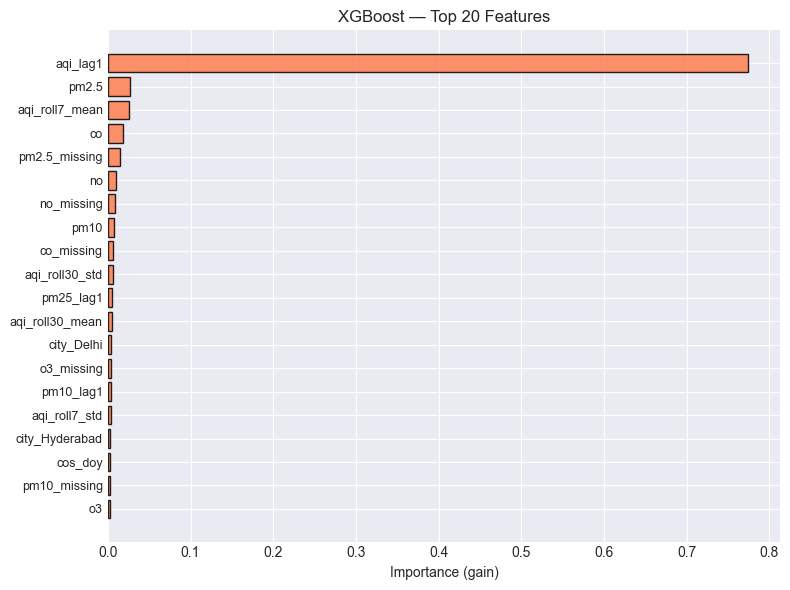

In [10]:
importances = xgb_final.feature_importances_
top_n = 20
order = np.argsort(importances)[-top_n:]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(top_n), importances[order], color='coral', edgecolor='black', alpha=0.85)
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_cols[i] for i in order], fontsize=9)
ax.set_xlabel('Importance (gain)')
ax.set_title('XGBoost — Top 20 Features')
plt.tight_layout()
plt.show()

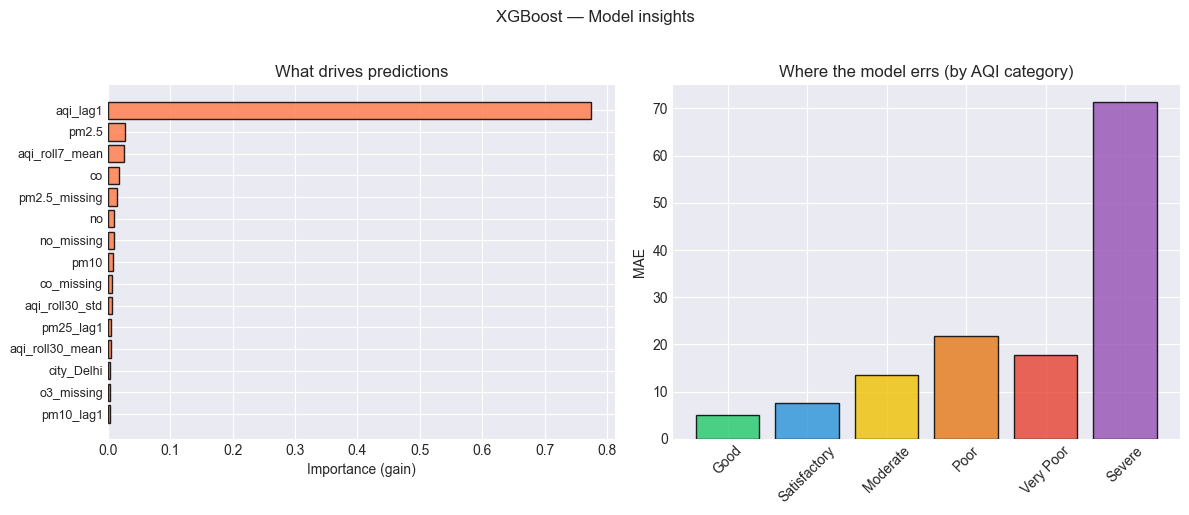

Saved → results/xgboost_slide_insights.png


In [11]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

try:
    _ = xgb_final
    _ = result_xgb
    _ = feature_cols
except NameError:
    from preprocessing import (
        load_and_prepare, impute, build_features,
        get_train_test, get_arrays, AQI_LABELS, CUTOFF_DATE,
    )
    df = load_and_prepare()
    df = impute(df)
    df, feature_cols = build_features(df)
    train_df, test_df = get_train_test(df)
    X_train, X_test, y_train_log, y_test_raw, y_test_log = get_arrays(train_df, test_df, feature_cols)
    xgb_final = xgb.XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1,
        objective='reg:squarederror',
    )
    xgb_final.fit(X_train, y_train_log)
    with open('results/xgboost_metrics.json') as f:
        data = json.load(f)
    result_xgb = data.get('tuned', data)  # use tuned metrics for plots

top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Feature importance (top 15)
order = np.argsort(xgb_final.feature_importances_)[-top_n:]
axes[0].barh(range(top_n), xgb_final.feature_importances_[order], color='coral', edgecolor='black', alpha=0.85)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels([feature_cols[i] for i in order], fontsize=9)
axes[0].set_xlabel('Importance (gain)')
axes[0].set_title('What drives predictions')

# Right: MAE by AQI category (from result_xgb)
mae_keys = [f'MAE_{c}' for c in AQI_LABELS if f'MAE_{c}' in result_xgb]
cats = [k.replace('MAE_', '') for k in mae_keys]
mae_vals = [result_xgb[k] for k in mae_keys]
colors = ['#2ecc71', '#3498db', '#f1c40f', '#e67e22', '#e74c3c', '#9b59b6'][:len(cats)]
axes[1].bar(cats, mae_vals, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_ylabel('MAE')
axes[1].set_title('Where the model errs (by AQI category)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('XGBoost — Model insights', fontsize=12, y=1.02)
plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/xgboost_slide_insights.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved → results/xgboost_slide_insights.png')

## 6. Residual diagnostics

Visualise prediction errors to identify systematic failure patterns by city, AQI range, and season.

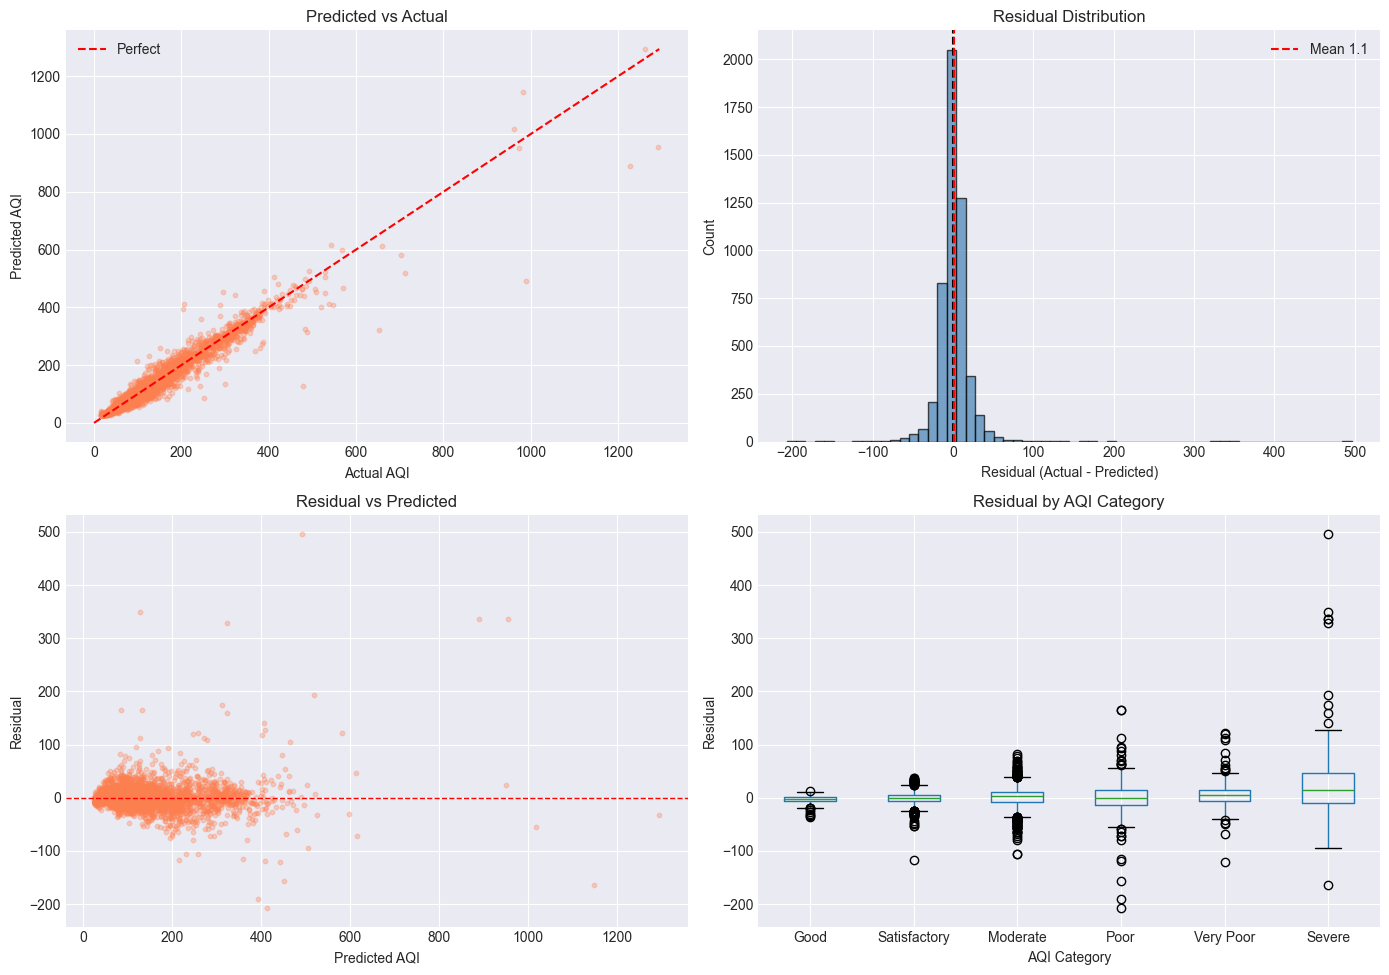

In [12]:
residuals = y_test_raw - y_pred_raw_xgb

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Predicted vs actual scatter
ax = axes[0, 0]
ax.scatter(y_test_raw, y_pred_raw_xgb, alpha=0.3, s=10, color='coral')
lim = max(y_test_raw.max(), y_pred_raw_xgb.max())
ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect')
ax.set(xlabel='Actual AQI', ylabel='Predicted AQI', title='Predicted vs Actual')
ax.legend()

# 2. Residual distribution
ax = axes[0, 1]
ax.hist(residuals, bins=60, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.axvline(residuals.mean(), color='red', ls='--', label=f'Mean {residuals.mean():.1f}')
ax.set(xlabel='Residual (Actual - Predicted)', ylabel='Count', title='Residual Distribution')
ax.legend()

# 3. Residual vs predicted (heteroscedasticity check)
ax = axes[1, 0]
ax.scatter(y_pred_raw_xgb, residuals, alpha=0.3, s=10, color='coral')
ax.axhline(0, color='red', ls='--', lw=1)
ax.set(xlabel='Predicted AQI', ylabel='Residual', title='Residual vs Predicted')

# 4. Residual by AQI category
ax = axes[1, 1]
cats = pd.cut(pd.Series(y_test_raw), bins=AQI_BINS, labels=AQI_LABELS)
res_df = pd.DataFrame({'residual': residuals, 'category': cats})
res_df.boxplot(column='residual', by='category', ax=ax)
ax.set(xlabel='AQI Category', ylabel='Residual', title='Residual by AQI Category')
ax.get_figure().suptitle('')

plt.tight_layout()
plt.show()

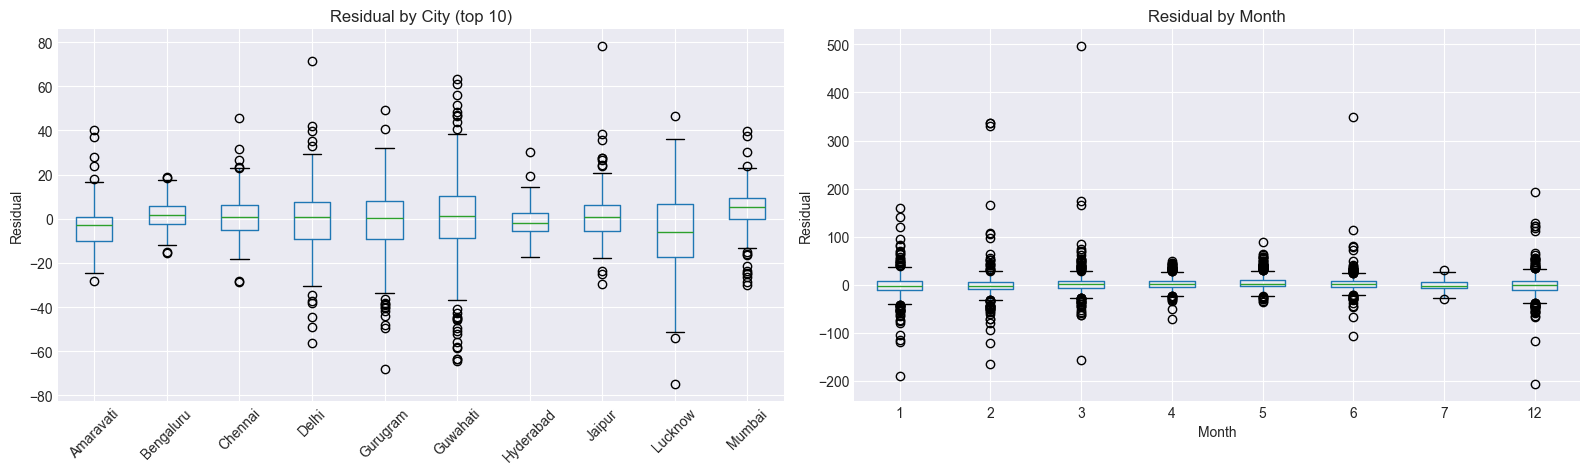

Per-city MAE (top 10 worst):
city
Ahmedabad       43.700287
Brajrajnagar    16.858465
Patna           16.629872
Guwahati        15.798312
Talcher         15.330196
Lucknow         14.647227
Jorapokhar      14.562681
Kochi           12.925186
Gurugram        12.660457
Amritsar        12.298252


In [13]:
# --- Residual by city (top 10 cities by test count) ---
diag_df = test_df[['city', 'date']].copy()
diag_df['residual'] = residuals
diag_df['month'] = diag_df['date'].dt.month

top_cities = diag_df['city'].value_counts().head(10).index
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# by city
ax = axes[0]
diag_df[diag_df['city'].isin(top_cities)].boxplot(
    column='residual', by='city', ax=ax, rot=45
)
ax.set(title='Residual by City (top 10)', xlabel='', ylabel='Residual')
ax.get_figure().suptitle('')

# by month
ax = axes[1]
diag_df.boxplot(column='residual', by='month', ax=ax)
ax.set(title='Residual by Month', xlabel='Month', ylabel='Residual')
ax.get_figure().suptitle('')

plt.tight_layout()
plt.show()

# per-city MAE
city_mae = diag_df.groupby('city')['residual'].apply(lambda x: np.abs(x).mean()).sort_values(ascending=False)
print('Per-city MAE (top 10 worst):')
print(city_mae.head(10).to_string())

## 7. Time-series overlay — predictions vs actuals for sample cities

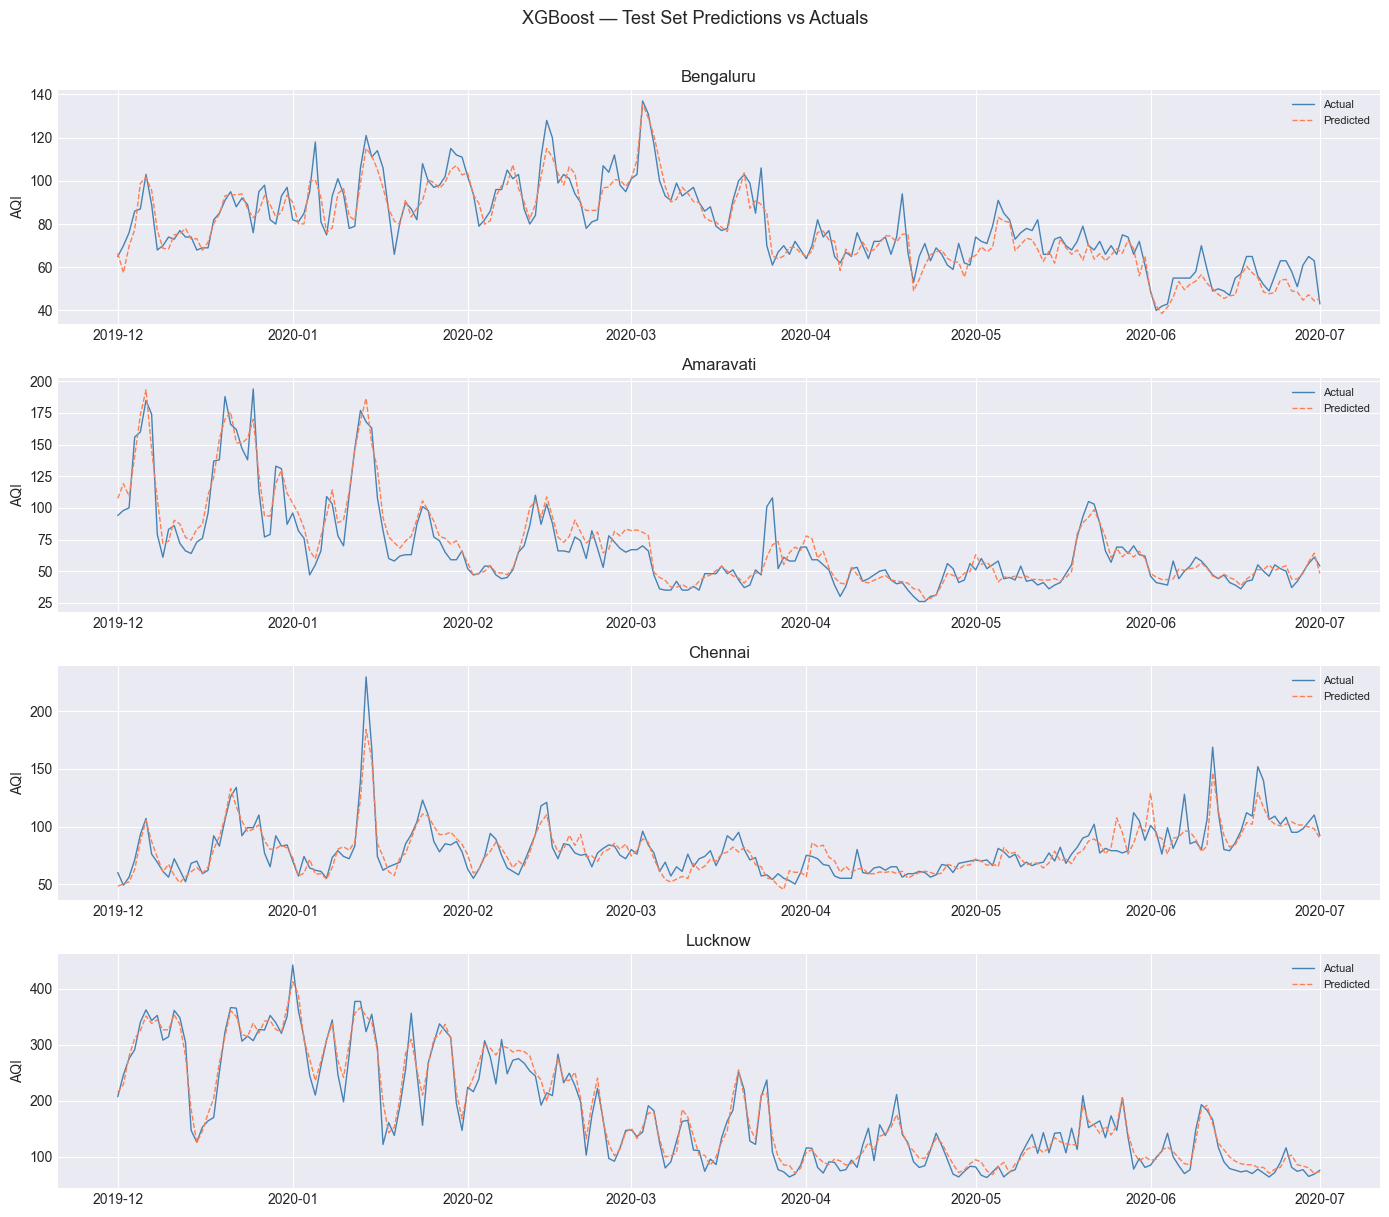

In [14]:
sample_cities = test_df['city'].value_counts().head(4).index.tolist()
ts_df = test_df[['city', 'date']].copy()
ts_df['actual'] = y_test_raw
ts_df['predicted'] = y_pred_raw_xgb

fig, axes = plt.subplots(len(sample_cities), 1,
                         figsize=(14, 3 * len(sample_cities)), sharex=False)

for ax, city in zip(axes, sample_cities):
    city_data = ts_df[ts_df['city'] == city].sort_values('date')
    ax.plot(city_data['date'], city_data['actual'], label='Actual', color='steelblue', lw=1)
    ax.plot(city_data['date'], city_data['predicted'], label='Predicted', color='coral', lw=1, ls='--')
    ax.set(ylabel='AQI', title=city)
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle('XGBoost — Test Set Predictions vs Actuals', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()